<a href="https://colab.research.google.com/github/Team-Teachmon/Teachmon-AI/blob/main/train.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from ast import literal_eval
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier  # 또는 XGBClassifier, LGBMClassifier
from sklearn.metrics import accuracy_score

# 1. 데이터 불러오기
df = pd.read_csv("2024_final_training_data_filtered.csv")

# 2. 리스트 형태로 저장된 문자열을 실제 리스트로 변환
df["학교시간표"] = df["학교 시간표"].apply(literal_eval)
df["방과후시간표"] = df["방과후 시간표"].apply(literal_eval)

# 3. 요일 및 교시 one-hot 인코딩
df = pd.get_dummies(df, columns=["요일", "교시"])

# 4. 입력값 (X), 출력값 (y) 구성
X = pd.concat([
    df["학교시간표"].apply(pd.Series),
    df["방과후시간표"].apply(pd.Series),
    df.filter(regex="요일_"),
    df.filter(regex="교시_"),
    df[["자습감독 횟수"]]
], axis=1)

# 💥 컬럼 이름을 모두 문자열(str)로 변환 (에러 방지)
X.columns = X.columns.astype(str)

y = df["자습감독 여부"]

# 5. 훈련/테스트 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 7. 예측 및 정확도 확인
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"🎯 자습감독 예측 정확도: {acc * 100:.2f}%")

🎯 자습감독 예측 정확도: 99.43%


In [3]:
print(model.score(X_train, y_train))
print(model.score(X_test, y_test))

0.9962650670590233
0.9943413309189678


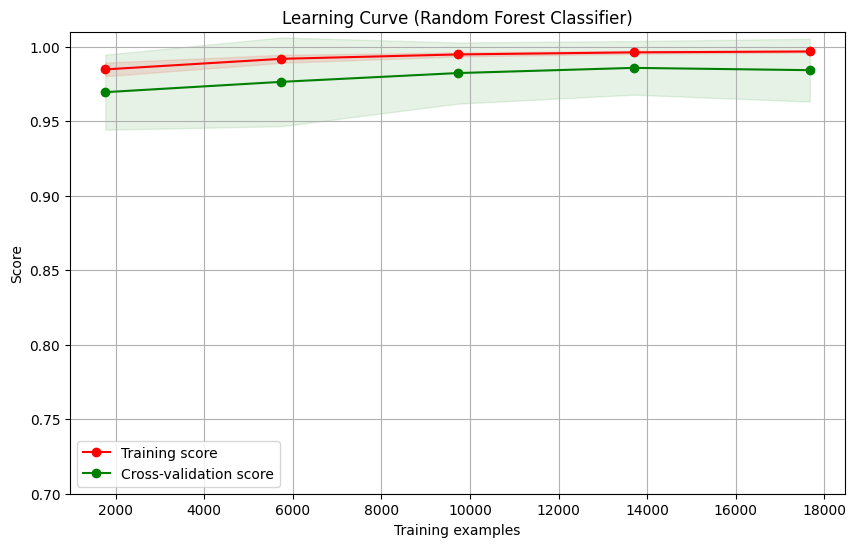

In [5]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
import numpy as np

# 학습 곡선 데이터 생성
train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5))

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

# 학습 곡선 시각화
plt.figure(figsize=(10, 6))
plt.title("Learning Curve (Random Forest Classifier)")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1,
                 color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Cross-validation score")
plt.legend(loc="best")
plt.ylim(0.7, 1.01) # y축 범위 설정 (이전 그래프와 동일하게)
plt.show()